In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
df = pd.read_csv('/forestfires.csv')
print(df.head())
print(df.info())
print(df.describe())

  month  day  FFMC   DMC     DC  ISI  temp  RH  wind  rain  ...  monthfeb  \
0   mar  fri  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0  ...         0   
1   oct  tue  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0  ...         0   
2   oct  sat  90.6  43.7  686.9  6.7  14.6  33   1.3   0.0  ...         0   
3   mar  fri  91.7  33.3   77.5  9.0   8.3  97   4.0   0.2  ...         0   
4   mar  sun  89.3  51.3  102.2  9.6  11.4  99   1.8   0.0  ...         0   

   monthjan  monthjul  monthjun  monthmar  monthmay  monthnov  monthoct  \
0         0         0         0         1         0         0         0   
1         0         0         0         0         0         0         1   
2         0         0         0         0         0         0         1   
3         0         0         0         1         0         0         0   
4         0         0         0         1         0         0         0   

   monthsep  size_category  
0         0          small  
1         0          small  

In [ ]:
df['month'] = df['month'].astype('category').cat.codes
df['day'] = df['day'].astype('category').cat.codes


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['month'] = le.fit_transform(df['month'])
df['day'] = le.fit_transform(df['day'])
df['size_category'] = le.fit_transform(df['size_category'])

In [ ]:
X = df.drop('area', axis=1)
y = df['area']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
model = Sequential()
model.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(8, activation='relu'))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 2597.7292 - mae: 12.2588 - val_loss: 628.6938 - val_mae: 7.2223
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2590.2527 - mae: 12.1654 - val_loss: 624.3403 - val_mae: 7.1862
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2582.8628 - mae: 12.1173 - val_loss: 620.2534 - val_mae: 7.1670
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2575.3040 - mae: 12.0862 - val_loss: 616.3910 - val_mae: 7.1510
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2566.9775 - mae: 12.0717 - val_loss: 612.6816 - val_mae: 7.1374
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2558.9819 - mae: 12.0657 - val_loss: 608.3003 - val_mae: 7.1233
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2548.8386 - mae: 12.0473 - val_loss: 604.6350 - val_mae: 7.1131
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2539.1096 - mae: 12.0432 - val_loss: 600.4872 - val_mae: 7.1144
Epoch 9/50
21/21 

In [ ]:
y_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)


RMSE: 104.08399917959764
R2 Score: 0.0809554201823417


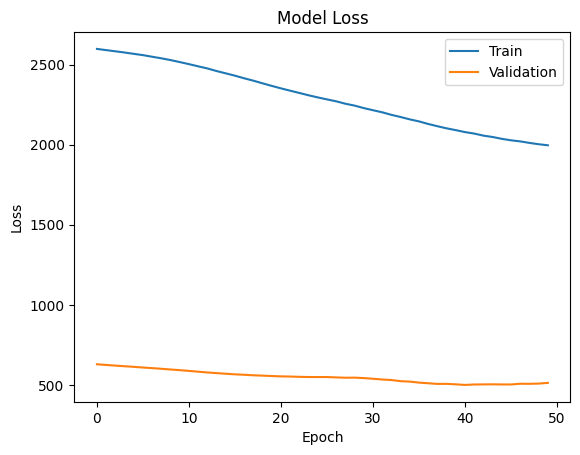

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()